In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bin import utils, spd2xyz


In [2]:
file = Path("/Users/loggiasr/Downloads/mt2tabsmeasured/amoled_1_cal.csv")
tmp_dir = Path("tmp")
tmp_dir.mkdir(parents=True, exist_ok=True)
xyz_file = tmp_dir / f"{file.stem}_measured_XYZ.csv"
spd2xyz.convert_spd_csv_to_xyz(file, xyz_file)
xyz_file


PosixPath('tmp/amoled_1_cal_measured_XYZ.csv')

In [3]:
valid, summary = utils.summarize_xyz_measurements([xyz_file])
summary


,id,n,X_mean,X_std,Y_mean,Y_std,Z_mean,Z_std
0,0,3,0.000267,0.000063,0.000286,0.000065,0.000385,0.000108
1,1,3,0.000928,0.000079,0.000983,0.000102,0.001108,0.000106
2,2,3,0.004348,0.000060,0.004710,0.000072,0.004591,0.000129
3,3,3,0.010480,0.000054,0.011361,0.000055,0.010646,0.000060
4,4,3,0.019200,0.000051,0.020822,0.000073,0.019499,0.000151
...,...,...,...,...,...,...,...,...
60,60,3,0.040379,0.000080,0.020865,0.000045,0.232577,0.000121
61,61,3,0.048520,0.000037,0.025049,0.000128,0.280079,0.000230
62,62,3,0.057281,0.000051,0.029414,0.000240,0.330748,0.000370
63,63,3,0.066810,0.000046,0.034291,0.000053,0.385829,0.000202


In [4]:
# Configuration
black_point_id = 0
white_point_id = 16
lut_out = Path("spec_output/mt2_linearized_rgb_lut_2026.tsv")


In [5]:
# Fit unified screen model (gamma + RGB<->XYZ transform)
calibration_df = pd.read_csv(xyz_file)
black_xyz = summary.loc[summary["id"] == black_point_id, ["X_mean", "Y_mean", "Z_mean"]].iloc[0].to_numpy(dtype=float)
white_xyz = summary.loc[summary["id"] == white_point_id, ["X_mean", "Y_mean", "Z_mean"]].iloc[0].to_numpy(dtype=float)
screen_model = utils.XYZRGBScreenModel(black_xyz=black_xyz, white_xyz=white_xyz)
screen_model.fit(calibration_df, mode="trc_matrix")
gamma_rgb = screen_model.gamma_rgb
gamma_fit_table = pd.DataFrame({
    "gun": ["R", "G", "B"],
    "gamma": gamma_rgb,
})
model_table = pd.DataFrame({
    "parameter": ["gamma_R", "gamma_G", "gamma_B", "black_X", "black_Y", "black_Z", "white_X", "white_Y", "white_Z", "rmse_X", "rmse_Y", "rmse_Z"],
    "value": [
        gamma_rgb[0], gamma_rgb[1], gamma_rgb[2],
        screen_model.black_xyz[0], screen_model.black_xyz[1], screen_model.black_xyz[2],
        screen_model.white_xyz[0], screen_model.white_xyz[1], screen_model.white_xyz[2],
        screen_model.fit_rmse_xyz[0], screen_model.fit_rmse_xyz[1], screen_model.fit_rmse_xyz[2],
    ],
})
print("Fitted gamma (R,G,B):", np.round(gamma_rgb, 4))
print("XYZ RMSE [X,Y,Z]:", np.round(screen_model.fit_rmse_xyz, 6))
print("Model variant:", screen_model.model_variant)
gamma_fit_table
model_table


Fitted gamma (R,G,B): [2.2829 2.2814 2.2015]
XYZ RMSE [X,Y,Z]: [0.014787 0.017842 0.007541]


,parameter,value
0,gamma_R,2.282896
1,gamma_G,2.281424
2,gamma_B,2.201525
3,black_X,0.000267
4,black_Y,0.000286
5,black_Z,0.000385
6,white_X,0.395600
7,white_Y,0.435587
8,white_Z,0.394349
9,rmse_X,0.014787


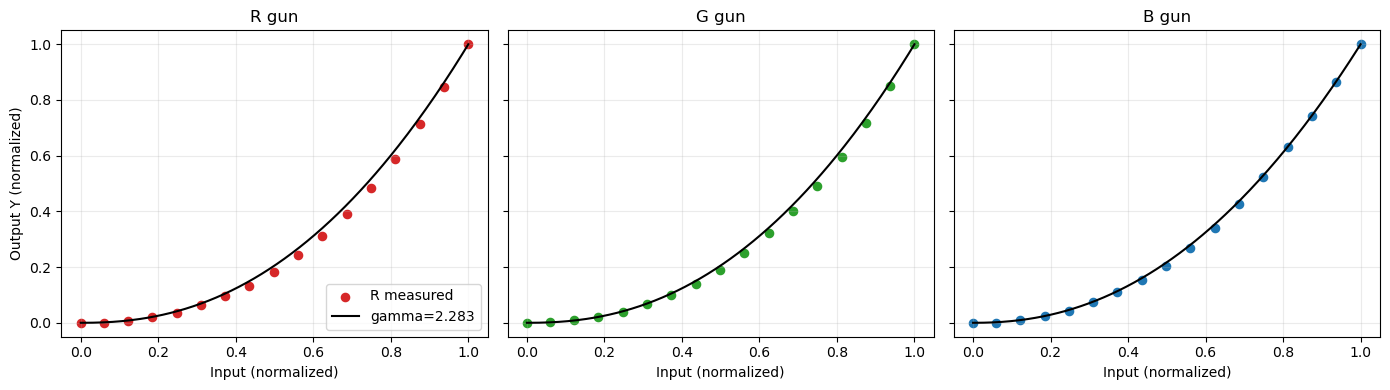

In [6]:
# Plot measured normalized gun responses vs fitted gamma curves
cal = calibration_df.copy()
for c in ["r", "g", "b", "Y"]:
    cal[c] = pd.to_numeric(cal[c], errors="coerce")
cal = cal.dropna(subset=["r", "g", "b", "Y"]).copy()

black_Y = float(screen_model.black_xyz[1])
guns = [("R", "r", "g", "b", "tab:red", gamma_rgb[0]),
        ("G", "g", "r", "b", "tab:green", gamma_rgb[1]),
        ("B", "b", "r", "g", "tab:blue", gamma_rgb[2])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, (name, ch, oth1, oth2, color, gamma) in zip(axes, guns):
    d = cal[(cal[oth1] == 0) & (cal[oth2] == 0)].copy()
    d = d.groupby(ch, as_index=False)["Y"].mean().sort_values(ch)
    x = np.clip(d[ch].to_numpy(dtype=float) / 255.0, 0.0, 1.0)
    y = np.clip(d["Y"].to_numpy(dtype=float) - black_Y, 0.0, None)
    y = y / y.max() if y.max() > 0 else y

    x_fit = np.linspace(0, 1, 256)
    y_fit = np.power(x_fit, gamma)

    ax.scatter(x, y, s=35, color=color, label=f"{name} measured")
    ax.plot(x_fit, y_fit, color="black", linewidth=1.5, label=f"gamma={gamma:.3f}")
    ax.set_title(f"{name} gun")
    ax.set_xlabel("Input (normalized)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Output Y (normalized)")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()


In [7]:
# Generate 256-entry linearized RGB LUT from fitted inverse gamma
target = np.linspace(0.0, 1.0, 256)
lut_df = pd.DataFrame({"ID": np.arange(256, dtype=int)})

for gun, gamma in zip(["R", "G", "B"], screen_model.gamma_rgb):
    vals = np.round(255.0 * np.power(target, 1.0 / gamma)).astype(int)
    vals = np.maximum.accumulate(vals)
    vals[0] = 0
    vals[-1] = 255
    lut_df[gun] = vals

lut_out.parent.mkdir(parents=True, exist_ok=True)
lut_df.to_csv(lut_out, sep="\t", index=False)
print(f"Saved LUT to {lut_out}")
lut_df


Saved LUT to spec_output/mt2_linearized_rgb_lut_2026.tsv


,ID,R,G,B
0,0,0,0,0
1,1,23,22,21
2,2,30,30,28
3,3,36,36,34
4,4,41,41,39
...,...,...,...,...
251,251,253,253,253
252,252,254,254,254
253,253,254,254,254
254,254,255,255,255


In [8]:
# Quick utility check: RGB<->XYZ and XYZ<->LUV using the fitted class
white_xyz = summary.loc[summary["id"] == white_point_id, ["X_mean", "Y_mean", "Z_mean"]].iloc[0].to_numpy(dtype=float)

rgb_white_pred = screen_model.xyz_to_rgb(white_xyz)
xyz_white_from_255 = screen_model.rgb_to_xyz([255, 255, 255])

luv_white = screen_model.xyz_to_cie_luv(white_xyz, reference_xyz=white_xyz)
xyz_white_back = screen_model.cie_luv_to_xyz(luv_white, reference_xyz=white_xyz)

check_table = pd.DataFrame({
    "metric": ["white XYZ -> predicted RGB", "RGB 255,255,255 -> XYZ", "white XYZ -> LUV", "LUV(white) -> XYZ"],
    "value": [
        rgb_white_pred.tolist(),
        np.round(xyz_white_from_255, 6).tolist(),
        np.round(luv_white, 6).tolist(),
        np.round(xyz_white_back, 6).tolist(),
    ],
})
check_table


,metric,value
0,white XYZ -> predicted RGB,"[244, 244, 248]"
1,"RGB 255,255,255 -> XYZ","[0.435699, 0.480366, 0.418267]"
2,white XYZ -> LUV,"[100.0, 0.0, 0.0]"
3,LUV(white) -> XYZ,"[0.3956, 0.435587, 0.394349]"


In [9]:
# Save fitted screen model parameters to JSON
if "screen_model" not in globals():
    raise RuntimeError("Run the model fit cell first.")

model_json_out = Path("spec_output/mt2_screen_model_2026.json")
saved_model_path = screen_model.save_json(model_json_out)
print(f"Saved screen model to {saved_model_path}")
saved_model_path


Saved screen model to spec_output/mt2_screen_model_2026.json


PosixPath('spec_output/mt2_screen_model_2026.json')